<a href="https://colab.research.google.com/github/ZIZOHH-008/Machine-Learning-Domestika/blob/main/AnalisisDatos_CaliforniaHouses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn
datos = pd.read_csv("CaliforniaHouses.csv")
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
datos.head()
# Estos son los datos/parámetros a tener en cuenta de una casa para valorarla

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
datos["ocean_proximity"]
# En la columna de "ocean_proximity hay varios tipos de datos diferentes"
# En lo siguiente, solo se ve algunos de estos

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [ ]:
datos["ocean_proximity"].value_counts()

# Con la función de .value_counts() se muestra la frecuencia de cada tipo de valor
# Los modelos de ML solo detectan datos numéricos

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
datos.info()

# Se nota que la variable 4 "total_bedrooms" tiene varias celdas vacías.
# Si el csv tiene celdas vacías, la máquina que se entrena con estos datos falla

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
'''
Se identifican 2 errores:
1. Una columna tiene tipos de datos que NO son números
2. Una columnas tiene datos vacios
'''

'\nSe identifican 2 errores:\n1. Una columna tiene tipos de datos que NO son números\n2. Una columnas tiene datos vacios\n'

In [ ]:
# Para borrar las filas de datos vacios identificadas:
datosSinHuecos = datos.dropna()
datosSinHuecos.info() #Ahora todos tienen igual cantidad

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [ ]:
# ocean_proximty no tiene datos numéricos, para convertirlos
'''
Usaremos Dummies / One-Hot Encoding
Como usar valores enteros por si está cerca del mar, o en una isla, o cerca de la playa da un "valor" que no es cierto a la
localidad, se usan dummies los caules dan valores booleanos (True/False) dependiendo de la categoría en la que esten.
Clasifica los datos por pertenencia sin dar un valor de "preferencia" o "mayoría"
'''

'\nUsaremos Dummies / One-Hot Encoding\nComo usar valores enteros por si está cerca del mar, o en una isla, o cerca de la playa da un "valor" que no es cierto a la \nlocalidad, se usan dummies los caules dan valores booleanos (True/False) dependiendo de la categoría en la que esten.\nClasifica los datos por pertenencia sin dar un valor de "preferencia" o "mayoría"\n'

In [ ]:
dummies = pd.get_dummies(datosSinHuecos["ocean_proximity"], dtype=int)
print(dummies)

       <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0              0       0       0         1           0
1              0       0       0         1           0
2              0       0       0         1           0
3              0       0       0         1           0
4              0       0       0         1           0
...          ...     ...     ...       ...         ...
20635          0       1       0         0           0
20636          0       1       0         0           0
20637          0       1       0         0           0
20638          0       1       0         0           0
20639          0       1       0         0           0

[20433 rows x 5 columns]


In [ ]:
datosSinHuecos.join(dummies)    #Se le agregan las columnas de dummies a los datos huecos
datosBuenos = datosSinHuecos.join(dummies)

In [ ]:
datosBuenos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,0,1,0


In [ ]:
# Ya no se necesita la columna de "ocean_proximity", para borrarla:
datosLimpios = datosBuenos.drop("ocean_proximity", axis=1)   #axis=1 indica que ocean_proximity es una columna y no una fila
datosLimpios.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [ ]:
datos.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# Resumen de la funcionalidad para visualización de datos de pandas

datos.head()     # Muestra los primeros datos, sirva para ver los encabezados
datos["ocean_proximity"]    # Permite ver algunos datos de una columna en específico
datos["ocean_proximity"].value_counts()   # Muestra ver la cantidad de datos por cada tipo de datos de una columna
datos.info()    # Da el total de datos por cada columna (y el tipo de cada una)
datos.describe()    # Permite ver Max, Min, Promedios y Percentiles

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

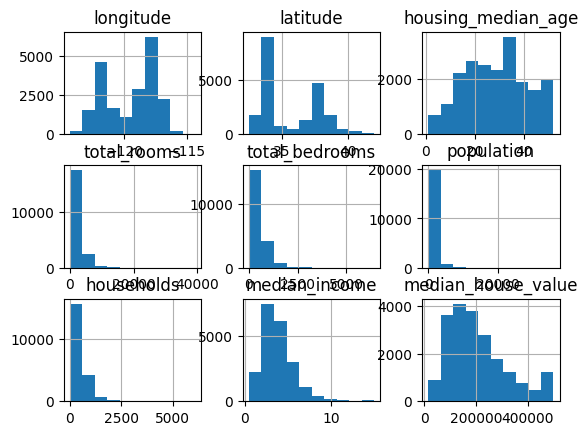

In [ ]:
#crear gráficas a partir de cada columna
datos.hist()

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

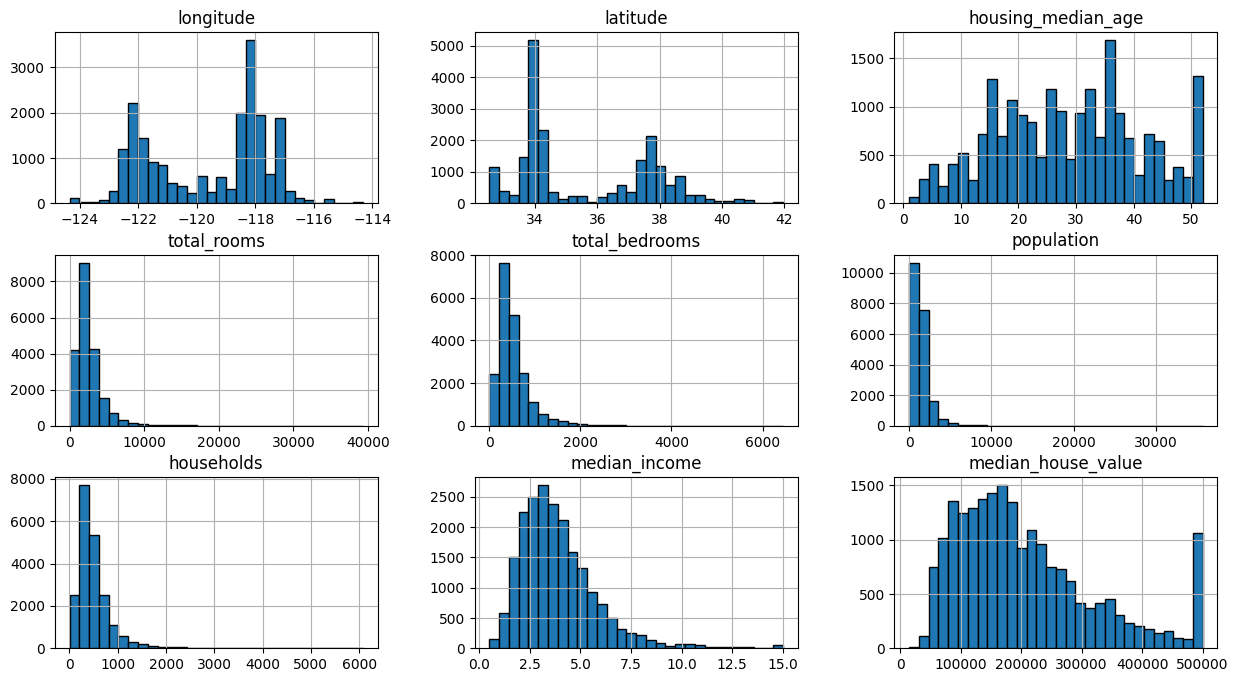

In [ ]:
datos.hist(figsize=(15,8), bins=30, edgecolor="Black")

      #   datos.hist(Tamaño gráficas, ancho barras, color borde)

In [ ]:
# Notar que en "median_income" tiene un pequeño brinco en x=15.0
# en "median_house_value" tiene un incremento enorme en el valor final

# Estos cambios repentinos afectan el entrenamiento de la máquina, toca limpiar los datos

TypeError: cannot convert the series to <class 'float'>

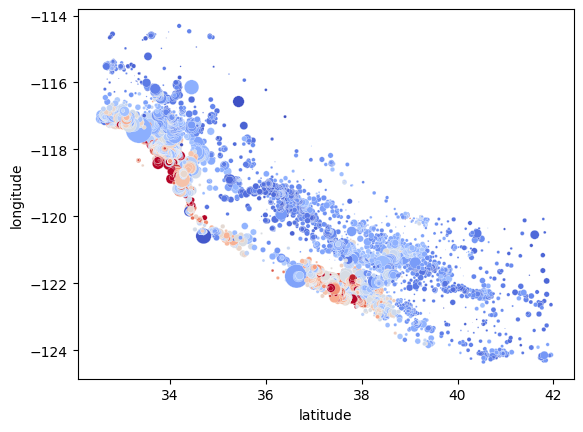

In [ ]:
seaborn.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm",
               s=datos["population"]/100)

# Da error, se supone que el último parámetro que da el tamaño a los puntos debe ser "size" y no "s"

In [ ]:
# El mapa anterior se parece MUCHO al mapa de california
'''
Notar que al poner la paleta "coolwarm", el color de los puntos dependen de los precios de las casa. Se concluye que
entre más cerca la casa al mar (menor longitud y latitud), más cara es
'''

'\nNotar que al poner la paleta "coolwarm", el color de los puntos dependen de los precios de las casa. Se concluye que\nentre más cerca la casa al mar (menor longitud y latitud), más cara es\n'

<Axes: xlabel='latitude', ylabel='longitude'>

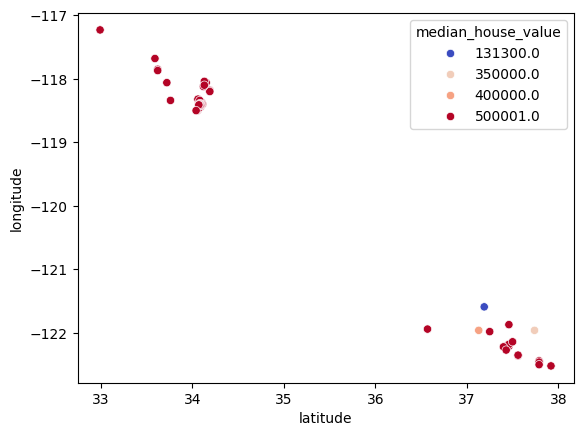

In [ ]:
# Con datos.describe() vimos que el máximo de median_income es 15, de resto son muy bajos. Por eso se pone un nuevo rango en
# los datos entregados a la gráfica para ver donde viven los más ricos (mayor a 14)

seaborn.scatterplot(x="latitude", y="longitude", data=datos[(datos.median_income>14)], hue="median_house_value", palette="coolwarm")


In [ ]:
# ANÁLIIS DE CORRELACIONES

In [ ]:
datosLimpios.corr()   # Esto calcula el coeficiente de correlación entre las columnas numéricas

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,0.320831,-0.055337,0.009501,-0.474714,0.046185
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,-0.446928,0.351084,-0.016662,0.358785,-0.161342
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,0.045553,-0.236968,0.017105,0.256149,0.020797
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,-0.003777,0.026477,-0.007603,-0.023647,-0.008674
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.018314,-0.006463,-0.004361,-0.019873,0.000679
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,0.073450,-0.019602,-0.010451,-0.061480,-0.023498
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,0.041883,-0.038265,-0.009119,-0.011280,0.002106
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.168715,-0.237536,-0.009281,0.056677,0.027351
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.257614,-0.484787,0.023525,0.160526,0.140378
<1H OCEAN,0.320831,-0.446928,0.045553,-0.003777,0.018314,0.073450,0.041883,0.168715,0.257614,1.000000,-0.607778,-0.013928,-0.314721,-0.342018


<Axes: >

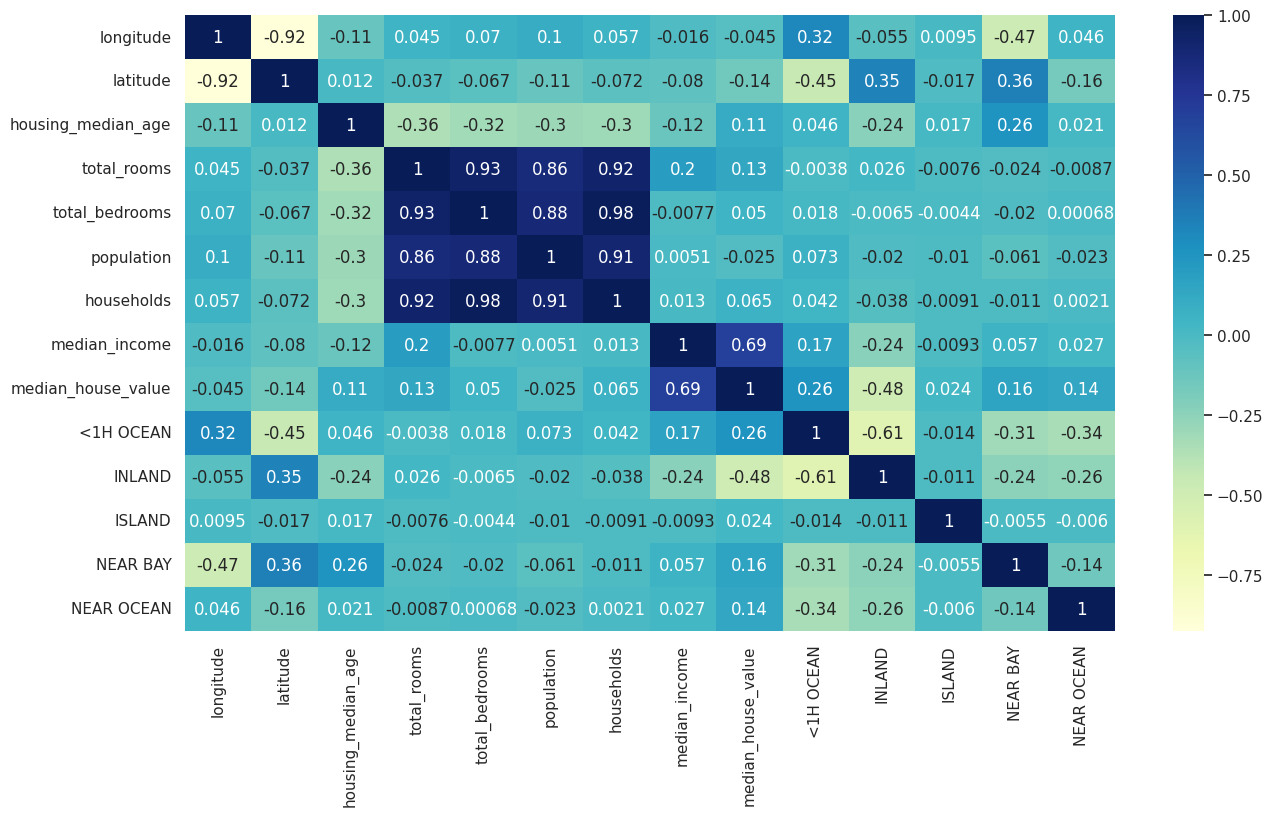

In [ ]:
seaborn.set(rc={'figure.figsize': (15,8)})     #Configura el tamaño de los cuadrados
seaborn.heatmap(datosLimpios.corr(), annot=True, cmap="YlGnBu")
  # (datos a graficar, annot es para ver los vlores en cada cuadro, color paleta)

In [ ]:
'''
La gráfica muestra la relacion entre todos los datos del conjunto
"¿Si modifico un valor, que tanto cambia otro valor (de otra columna?

Donde chocan los mismo datos, la relación es perfecta, por ejemplo, entre Latitude y Latitude el valor es 1
Si el valor de correlación es -1, es porque son perfectamente inversos (si uno aumenta, el otro disminuye)

Nos interesa ver como se relacionan las otras variables con el precio, en la gráfica se puede apreciar en su columna y fila
'''

#Para ver exclusivamente la columan deseada organizando en orden sus porcentaje de correlación:

In [ ]:
datosLimpios.corr()["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688355
<1H OCEAN,0.257614
NEAR BAY,0.160526
NEAR OCEAN,0.140378
total_rooms,0.133294
housing_median_age,0.106432
households,0.064894
total_bedrooms,0.049686
ISLAND,0.023525


In [ ]:
'''
COSAS NOTABLES DEL ANÁLISIS
  - Entre más ingresos reciben las persona de la localidad, más cara es la casa
  - InLand es lejanía del mal; entre más lejos esté, más barata es; entre más cerca, más cara
  - Las correlaciones de 0.0XXX son irrelevantes, de resto son analizables
'''